### Cycle-of this dataset
Project Structure Suggestion

Medical Project me:

Data Cleaning

EDA (age vs disease graph)

Logistic Regression

Random Forest

Compare metrics

Confusion Matrix

ROC Curve

Conclusion


In [26]:
# All import here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [27]:
# LoadDataset of this csv file
df=pd.read_csv('HeartDiseaseTrain-Test.csv')


In [28]:
df.shape

(1025, 14)

In [29]:
# Check the msisinng Value
df.isnull().sum()

age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64

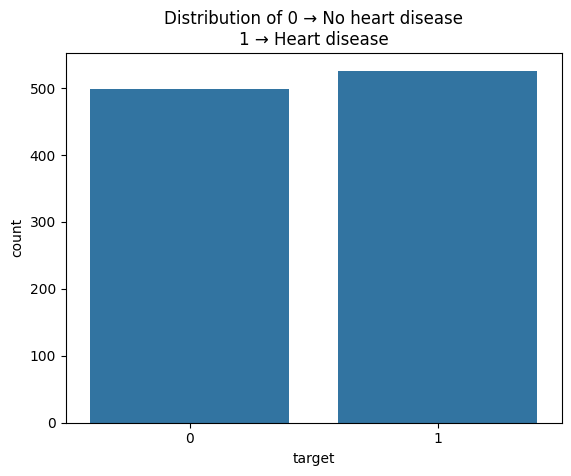

In [30]:
sns.countplot(x='target', data=df)
plt.title("Distribution of 0 → No heart disease\n1 → Heart disease")
plt.show()

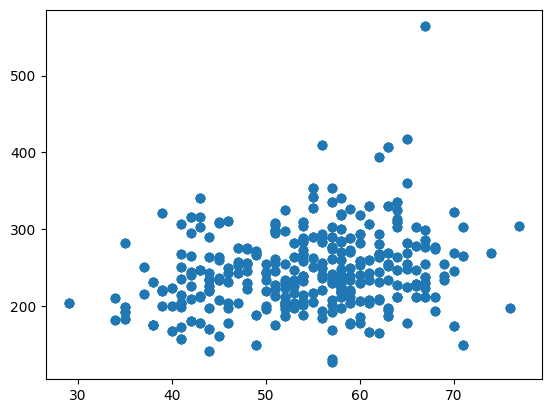

In [31]:
plt.scatter(df['age'],df['cholestoral'])

In [32]:
x=df.drop('target',axis=1)
y=df['target']

In [33]:
# X-Size of Data
x.shape

(1025, 13)

In [34]:
# Count the value of this target
df['target'].value_counts()
df['target'].value_counts(normalize=True)*100

target
1    51.317073
0    48.682927
Name: proportion, dtype: float64

In [35]:
# Check the value type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

In [36]:
num_cols = x.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

Index(['age', 'resting_blood_pressure', 'cholestoral', 'Max_heart_rate',
       'oldpeak'],
      dtype='object')


In [37]:
num_cols = x.select_dtypes(include=['object']).columns
print(num_cols)

Index(['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg',
       'exercise_induced_angina', 'slope', 'vessels_colored_by_flourosopy',
       'thalassemia'],
      dtype='object')


In [38]:
# Devied the Numerical and Categorical data
Categorical=['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg',
       'exercise_induced_angina', 'slope', 'vessels_colored_by_flourosopy',
       'thalassemia']

Numerical=['age','resting_blood_pressure','cholestoral','Max_heart_rate','oldpeak']

In [39]:
# ColumnTransForms Multipel data
preprocessor=ColumnTransformer(transformers=[
    ('Num',StandardScaler(),Numerical),
    ('Cat',OneHotEncoder(drop="first", handle_unknown="ignore"),Categorical),

])
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [40]:
# Mannual without pipeline
# rf=RandomForestClassifier()
# rf.fit(x_train_transformed,y_train)
# y_pred=rf.predict(x_test_transformed)
# from sklearn.metrics import accuracy_score
# score=accuracy_score(y_test,y_pred)
# print("Accuracy-Score:",score)

In [41]:
# with the help of pipeline
model=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ('Classifier',RandomForestClassifier())
])
model.fit(x_train,y_train)

,steps,"[('preprocessor', ...), ('Classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Num', ...), ('Cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [42]:

y_pred=model.predict(x_test)

In [43]:
# Check the accuracy
score=accuracy_score(y_test,y_pred)
print(score)

0.9853658536585366


In [44]:
# User Input-Site
new_patient = pd.DataFrame({
    'age':[50],
    'sex':['Female'],
    'chest_pain_type':['Typical angina'],
    'resting_blood_pressure':[130],
    'cholestoral':[203],
    'fasting_blood_sugar':['Lower than 120 mg/ml'],
    'rest_ecg':['Normal'],
    'Max_heart_rate':[1500],
    'exercise_induced_angina':['No'],
    'oldpeak':[1.5],
    'slope':['Flat'],
    'vessels_colored_by_flourosopy':['Zero'],
    'thalassemia':['Fixed Defect']
})

In [45]:
#Prediction Value
prediction=model.predict(new_patient)
print(prediction)

[1]


In [46]:
print(model.predict_proba(new_patient))

[[0.11 0.89]]


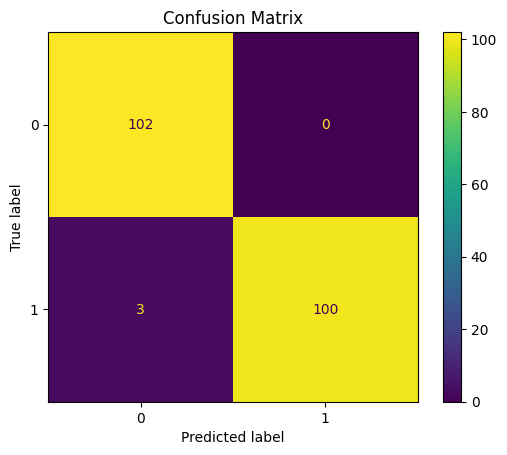

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

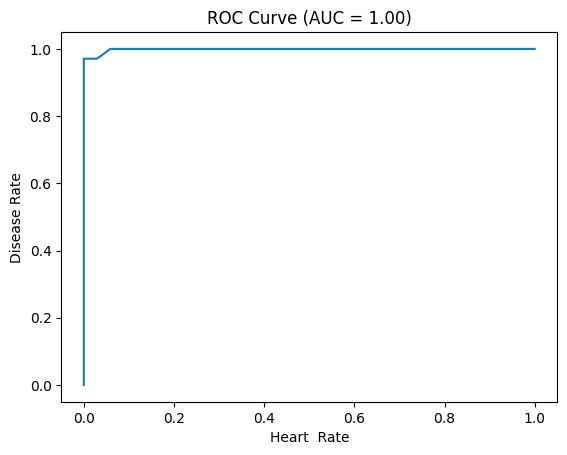

In [48]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(x_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label=1)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("Heart  Rate")
plt.ylabel("Disease Rate")
plt.title(f"ROC Curve (AUC = {auc_score:.2f})")
plt.show()

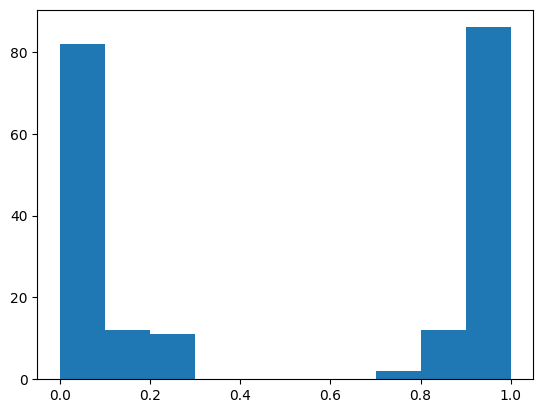

In [49]:
y_prob = model.predict_proba(x_test)[:,1]
plt.hist(y_prob)
plt.show()